In [20]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial as fac
from scipy.special import gamma,beta

#include error calculations by comparing %diff at lots of points and averaging

In [21]:
pi=np.pi
parameter=(2*pi)**.5
e=np.exp(1)

def Choose(a,b):
    return fac(a)/(fac(b)*fac(a-b))

def Normal(x,mu,sigma):
    u=(x-mu)/sigma
    return 1/(sigma*parameter)*e**(-.5*u**2)

def Binomial(n,p,nums):
    res=[]
    for i in nums:
        res.append(Choose(n,i)*(p**i)*((1-p)**(n-i)))
    return res

def Negative_Binomial(r,p,nums):
    res=[]
    for i in nums:
        res.append(Choose(i-1,r-1)*(p**r)*(1-p)**(i-r))
    return res

def Poisson(l,nums):
    res=[]
    for i in nums:
        res.append(e**(-l)*(l**i)*1/(fac(i)))
    return res

def Hypergeometric(N,K,n,k):
    res=[]
    for i in k:
        res.append((Choose(K,i))*(Choose(N-K,n-i))/(Choose(N,n)))
    return res

def Gamma(x,a,t):
    return (x**(a-1)*e**(-x/t))/((t**a)*gamma(a))

def Beta(x,a,b):
    return (x**(a-1)*(1-x)**(b-1))/beta(a,b)


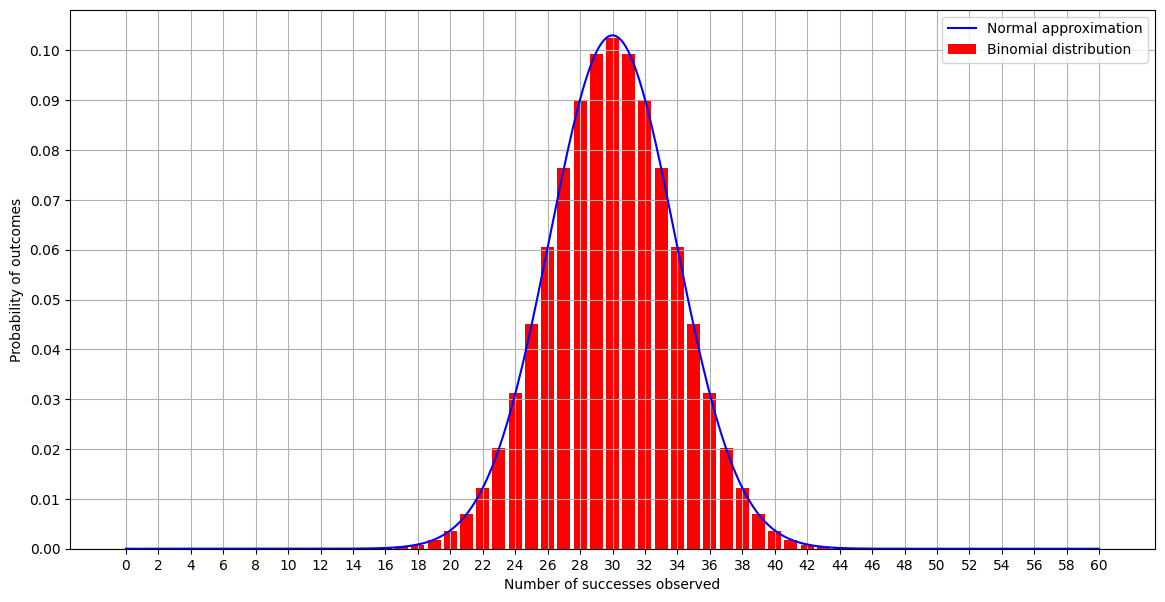

In [22]:
#Normal approximation for the Binomial distribution
#Works best for n>30 and p≈.5

#Number of trials
n=60
#Probability of success for each trial
p=.5
#Number of observed successes
nums=[]
for i in range(n+1):
    nums.append(i)

#Normal approximation parameters
x=np.linspace(0,n,1000)
mu=n*p
sigma=(n*p*(1-p))**.5

#Grid spacing
xinterval=2
yinterval=.01

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,n+1,xinterval))
plt.yticks(np.arange(0,1.1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probability of outcomes')
plt.bar(nums,Binomial(n,p,nums),label='Binomial distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),label='Normal approximation',color='b')
plt.legend()
plt.grid()
plt.show()

In [23]:
#error for norm approx of bin
#please run cell above before this cell

multiplier=1

lower=round(max(mu-multiplier*sigma,0))
upper=round(min(mu+multiplier*sigma,n))

values=[]
for i in range(lower,upper+1):
    values.append(i)

binomial_values=Binomial(n,p,values)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(binomial_values-normal_values)/binomial_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 0.249%
Median of the approximation's discrepancy: 0.311%
Standard deviation of the approximation's discrepancy: 0.134%


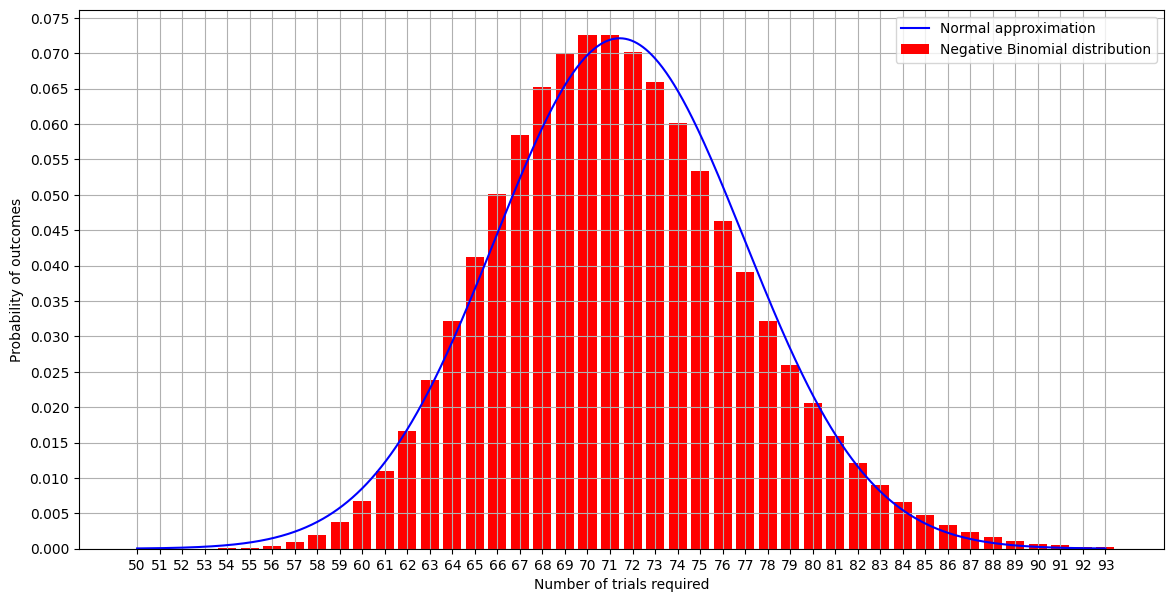

In [24]:
#Normal approximation for the Negative Binomial distribution
#Works best for r>40 and p<.8

#Number of successful trials
r=50
#Probability of success for each trial
p=.7
#x-axis scale
x=1.3
#Number of trials until r successes
nums=[]
y=round(x*r/p)
for i in range(r,y+1):
    nums.append(i)

#Normal approximation parameters
x=np.linspace(r,y,1000)
mu=r/p
sigma=(r*(1-p)/(p**2))**.5

#Grid spacing
xinterval=1
yinterval=.005

plt.figure(figsize=(14,7))
plt.xticks(np.arange(r,1+y,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of trials required')
plt.ylabel('Probability of outcomes')
plt.bar(nums,Negative_Binomial(r,p,nums),label='Negative Binomial distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),label='Normal approximation',color='b')
plt.legend()
plt.grid()
plt.show()

In [25]:
#error for norm approx of negbin
#please run cell above before this cell

multiplier=1
lower=round(max(r,mu-multiplier*sigma))
upper=round(mu+multiplier*sigma)

values=[]
for i in range(lower,upper+1):
    values.append(i)

negative_binomial_values=Negative_Binomial(r,p,values)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(negative_binomial_values-normal_values)/negative_binomial_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 7.341%
Median of the approximation's discrepancy: 8.191%
Standard deviation of the approximation's discrepancy: 3.492%


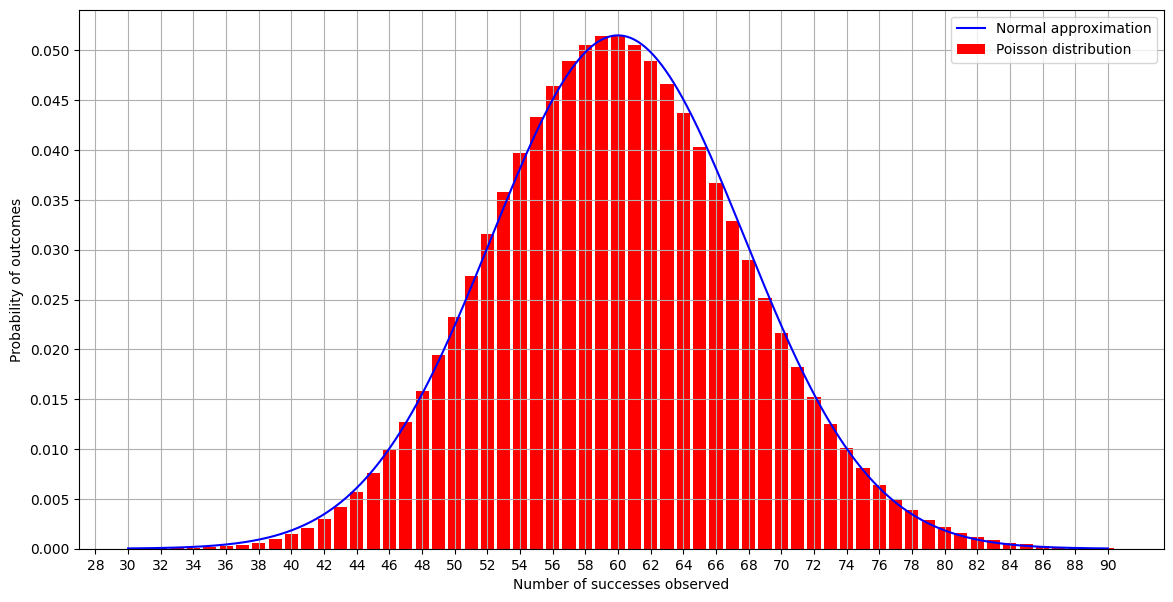

In [26]:
#Normal approximation for the Poisson distribution
#Works best for l>20

#Average number of successes in a given space or time
l=60
#x-axis scale
x=1.5
#Number of observed successes
nums=[]
for i in range(1+round(l/2),1+round(x*l)):
    nums.append(i)

#Normal approximation parameters
mu=l
sigma=l**.5
x=np.linspace(round(l/2),max(nums),1000)

#Grid spacing
xinterval=2
yinterval=.005

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,max(nums)+xinterval,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probability of outcomes')
plt.bar(nums,Poisson(l,nums),label='Poisson distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),label='Normal approximation',color='b')
plt.legend()
plt.grid()
plt.show()

In [27]:
#error for norm approx of poi

multiplier=1

lower=round(max(0,mu-multiplier*sigma))
upper=round(mu+multiplier*sigma)

values=[]
for i in range(lower,upper+1):
    values.append(i)

poisson_values=Poisson(l,values)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(poisson_values-normal_values)/poisson_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 2.831%
Median of the approximation's discrepancy: 3.118%
Standard deviation of the approximation's discrepancy: 1.35%


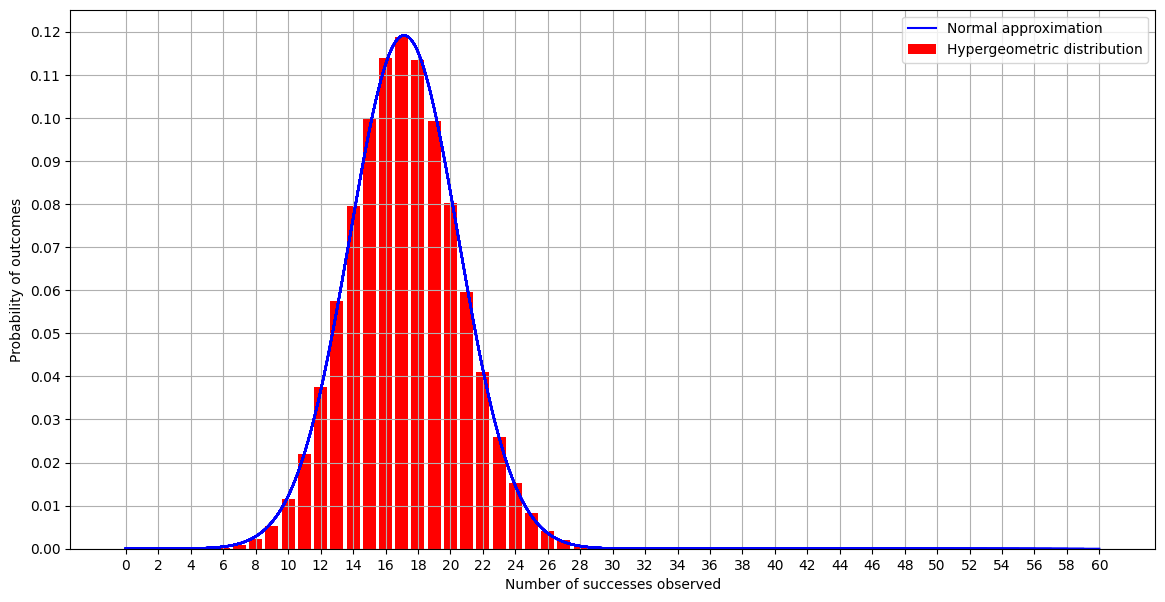

In [28]:
#Normal approximation for the Hypergeometric distribution
#Works best for N>10n, .1<K/N<.9 and n>30

#Population size
N=700
#Number of successes in population
K=200
#Sample size
n=60
#Number of observed successes in the sample
k=[]
for i in range (1+min(K,n)):
    k.append(i)

#Normal approximation parameters
mu=n*K/N
sigma=((n*K*(N-K)*(N-n))/(N**2*(N-1)))**.5
x=np.linspace(0,k,1000)

#Grid spacing
xinterval=2
yinterval=.01

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,n+1,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probability of outcomes')
plt.bar(k,Hypergeometric(N,K,n,k),label='Hypergeometric distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),color='b')

plt.plot((0),(0),label='Normal approximation',color='b') #here for label

plt.legend()
plt.grid()
plt.show()

In [29]:
#error for norm approx of hyper

multiplier=2

lower=round(max(0,mu-multiplier*sigma))
upper=round(min(n,mu+multiplier*sigma))

values=[]
for i in range(lower,upper+1):
    values.append(i)

hypergeometric_values=Hypergeometric(N,K,n,values)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(hypergeometric_values-normal_values)/hypergeometric_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 2.605%
Median of the approximation's discrepancy: 2.782%
Standard deviation of the approximation's discrepancy: 1.583%


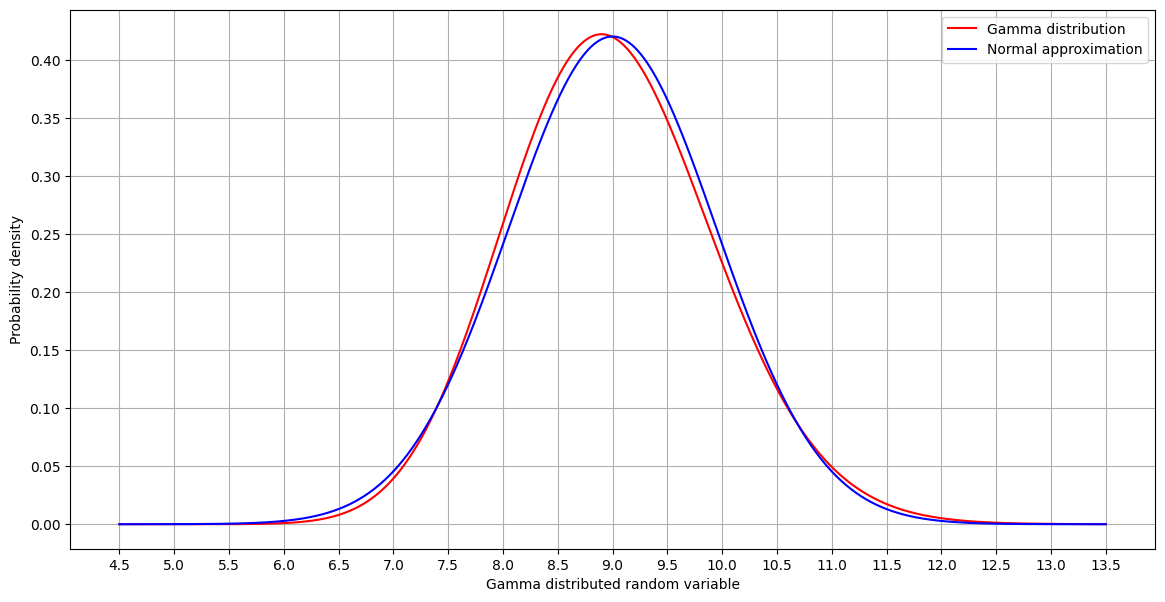

In [30]:
#Normal approximation for the Gamma distribution
#Works best for a>40

#Parameter representing the number of successes
a=90
#Parameter representing the average time between successes
t=.1

#Normal approximation parameters
mu=a*t
sigma=(a*t**2)**.5
x=np.linspace(.5*mu,1.5*mu,1000)

#Grid spacing
xinterval=.5
yinterval=.05

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,2*mu,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Gamma distributed random variable')
plt.ylabel('Probability density')
plt.plot(x,Gamma(x,a,t),label='Gamma distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),label='Normal approximation',color='b')
plt.legend()
plt.grid()
plt.show()

In [31]:
#error for norm approx of gamma

multiplier=1
spacing=1000

lower=max(0,mu-multiplier*sigma)
upper=mu+multiplier*sigma

values=np.linspace(lower,upper,spacing)

gamma_values=Gamma(values,a,t)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(gamma_values-normal_values)/gamma_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 4.4%
Median of the approximation's discrepancy: 4.84%
Standard deviation of the approximation's discrepancy: 2.171%


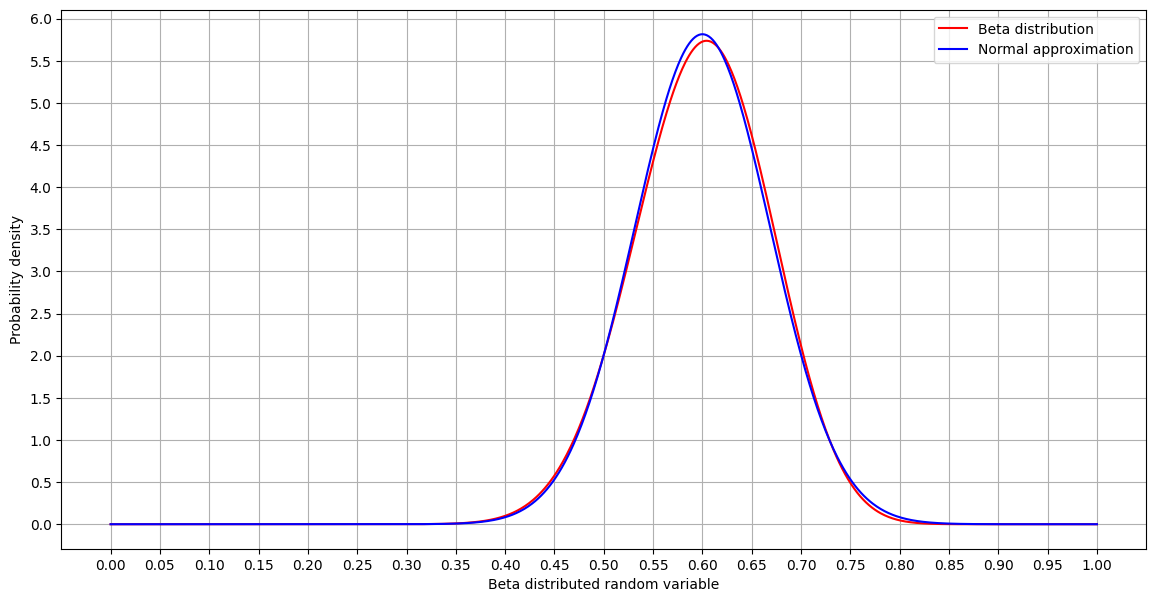

In [32]:
#Normal approximation for the Beta distribution
#Works best for a≈b and a,b>10

#Parameters that determine shape and skew
a=30
b=20

#Normal approximation parameters
mu=a/(a+b)
sigma=((a*b)/((a+b)**2*(a+b+1)))**.5
x=np.linspace(0,1,1000)

#Grid spacing
xinterval=.05
yinterval=.5

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,1.01,xinterval))
plt.yticks(np.arange(0,a+b,yinterval))
plt.xlabel('Beta distributed random variable')
plt.ylabel('Probability density')
plt.plot(x,Beta(x,a,b),label='Beta distribution',color='r')
plt.plot(x,Normal(x,mu,sigma),label='Normal approximation',color='b')
plt.legend()
plt.grid()
plt.show()

In [33]:
#error for norm approx of beta

multiplier=1
spacing=1000

lower=max(0,mu-multiplier*sigma)
upper=min(1,mu+multiplier*sigma)

values=np.linspace(lower,upper,spacing)

beta_values=Beta(values,a,b)
normal_values=Normal(np.array(values),mu,sigma)
results=100*np.abs(beta_values-normal_values)/beta_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 2.608%
Median of the approximation's discrepancy: 2.997%
Standard deviation of the approximation's discrepancy: 1.212%


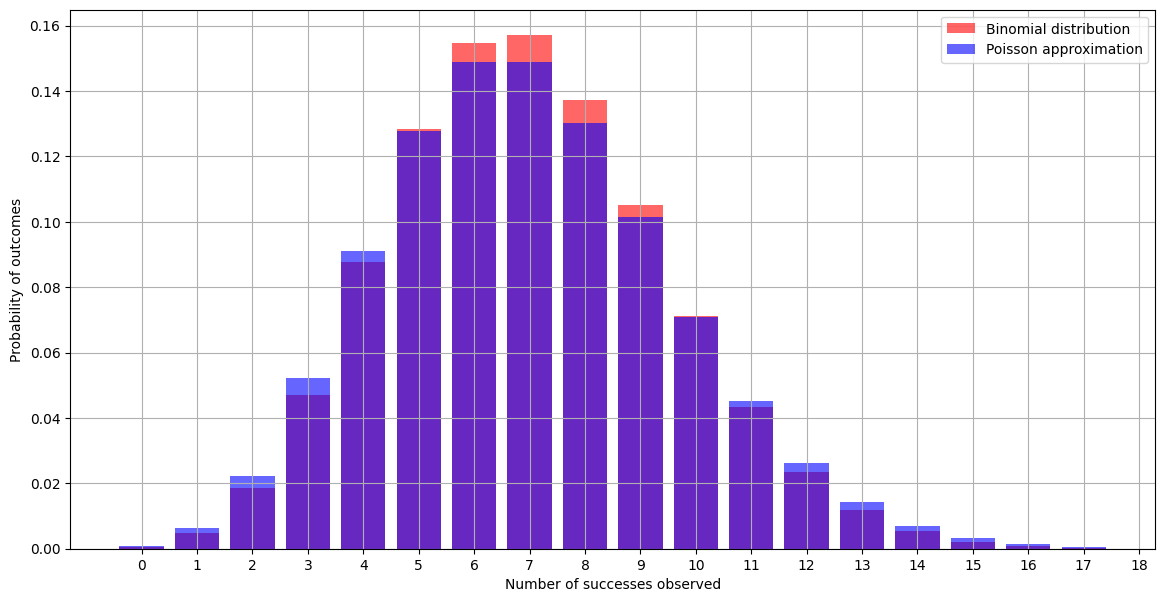

In [34]:
#Poisson approximation for the Binomial distribution
#Works best for n>50 and p≈0

#Number of trials
n=70
#Probability of success for each trial
p=.1
#x-axis scale
x=2.5
#Approximation for the expected number of observed successes
l=n*p
#Number of observed successes
nums=[]
for i in range(round(x*l)):
    nums.append(i)

#Grid spacing
xinterval=1
yinterval=.02

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,n,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probability of outcomes')
plt.bar(nums,Binomial(n,p,nums),label='Binomial distribution',color='r',alpha=.6)
plt.bar(nums,Poisson(l,nums),label='Poisson approximation',color='b',alpha=.6)
plt.legend()
plt.grid()
plt.show()

In [35]:
#error for poi approx of bin

multiplier=1
mu=n*p
sigma=mu**.5

lower=round(max(0,mu-multiplier*sigma))
upper=round(mu+multiplier*sigma)

values=[]
for i in range(lower,upper+1):
    values.append(i)

binomial_values=np.array(Binomial(n,p,values))
poisson_values=np.array(Poisson(l,values))
results=100*np.abs(binomial_values-poisson_values)/binomial_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 3.229%
Median of the approximation's discrepancy: 3.613%
Standard deviation of the approximation's discrepancy: 1.826%


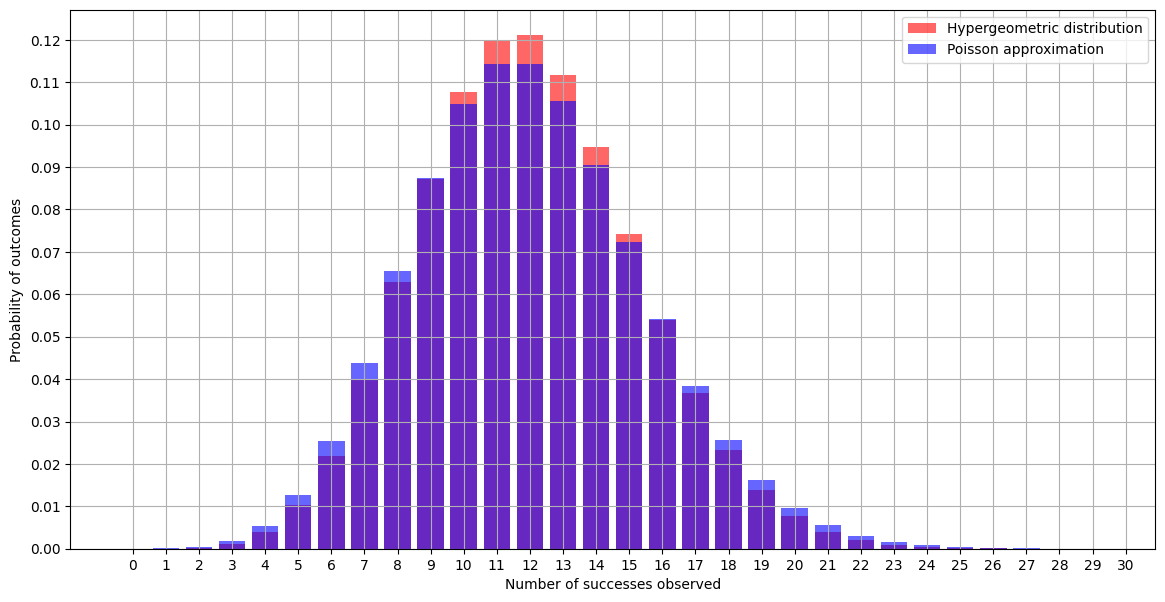

In [59]:
#Poisson approximation of the Hypergeometric distribution
#Works best for N>20n, K/N<.1 and n>50

#Population size
N=5000
#Number of successes in population
K=400
#Sample size
n=150
#Approximation for the expected number of observed successes in the sample
l=n*K/N
#x-axis scale
x=2.5
#Number of observed successes in sample
k=[]
for i in range(round(x*l)):
    k.append(i)

#Grid spacing
xinterval=1
yinterval=.01

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,n,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probability of outcomes')
plt.bar(k,Hypergeometric(N,K,n,k),label='Hypergeometric distribution',color='r',alpha=.6)
plt.bar(k,Poisson(l,k),label='Poisson approximation',color='b',alpha=.6)
plt.legend()
plt.grid()
plt.show()

In [65]:
#error for poi approx of hyper

multiplier=1

mu=l
sigma=l**.5

lower=round(max(0,mu-multiplier*sigma))
upper=round(min(n,mu+multiplier*sigma))

values=[]
for i in range(lower,upper+1):
    values.append(i)

hypergeometric_values=np.array(Hypergeometric(N,K,n,values))
poisson_values=Poisson(l,values)
results=100*np.abs(hypergeometric_values-poisson_values)/hypergeometric_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 3.664%
Median of the approximation's discrepancy: 4.528%
Standard deviation of the approximation's discrepancy: 1.79%


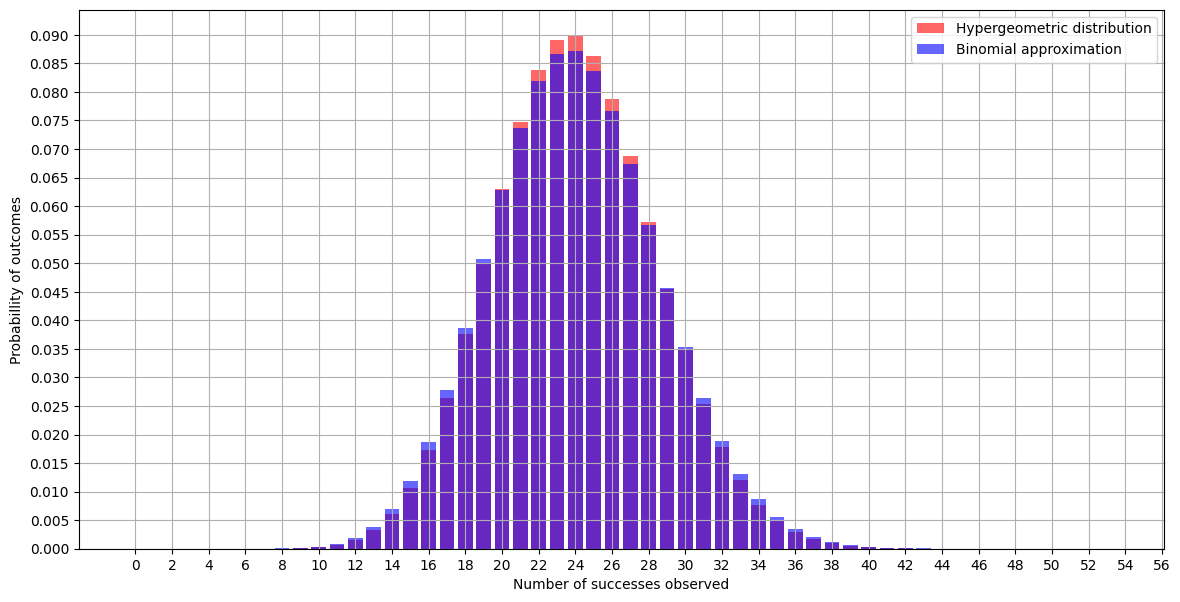

In [74]:
#Binomial approximation of the Hypergeometric distribution
#Works best for N>10n and n>50

#Population size
N=3000
#Number of successes in population
K=400
#Sample size
n=180
#Approximation for the probability of an observed success
p=K/N
#x-axis scale
x=.3
#Number of observed successes in sample
k=[]
for i in range(round(x*n)):
    k.append(i)

#Grid spacing
xinterval=2
yinterval=.005

plt.figure(figsize=(14,7))
plt.xticks(np.arange(0,1+n,xinterval))
plt.yticks(np.arange(0,1,yinterval))
plt.xlabel('Number of successes observed')
plt.ylabel('Probabillity of outcomes')
plt.bar(k,Hypergeometric(N,K,n,k),label='Hypergeometric distribution',color='r',alpha=.6)
plt.bar(k,Binomial(n,p,k),label='Binomial approximation',color='b',alpha=.6)
plt.legend()
plt.grid()
plt.show()

In [79]:
#error for bin approx of hyper

multiplier=1

mu=n*p
sigma=(mu*(1-p))**.5

lower=round(max(0,mu-multiplier*sigma))
upper=round(min(n,mu+multiplier*sigma))

values=[]
for i in range(lower,upper+1):
    values.append(i)

hypergeometric_values=np.array(Hypergeometric(N,K,n,values))
binomial_values=Binomial(n,p,values)
results=100*np.abs(hypergeometric_values-binomial_values)/hypergeometric_values

print(f"Mean of the approximation's discrepancy: {round(np.mean(results),3)}%")
print(f"Median of the approximation's discrepancy: {round(np.median(results),3)}%")
print(f"Standard deviation of the approximation's discrepancy: {round(np.std(results),3)}%")

Mean of the approximation's discrepancy: 1.808%
Median of the approximation's discrepancy: 2.027%
Standard deviation of the approximation's discrepancy: 1.004%
